In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

# Proses Pengumpulan Data

Dataset ulasan pelanggan dikumpulkan dari Instant Data Scraper Extension untuk kategori Kerajinan. 

- **Metode Pengumpulan**: Menggunakan Instant Data Scraper Extension untuk scraping ulasan dari tempat kerajinan.
- **Tools/Teknologi**: Python dengan library requests dan Instant Data Scraper Extension.
- **Cakupan Sumber Data dan Periode Waktu**: Ulasan dari beberapa tempat kerajinan berbeda.
- **Proses Pembersihan**: 
  - Hapus ulasan kosong atau terlalu pendek.
  - Deduplikasi berdasarkan teks ulasan.
  - Normalisasi teks (lowercase, hapus emoji).

Jumlah data akhir: 1258 ulasan unik.

In [2]:
file_path = "../dataset/Kelp3_dataset_anotasi.jsonl" 

data = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

df = pd.DataFrame(data)

df.head()

,text,tokens,spans,_input_hash,_task_hash,options,_view_id,config,accept,answer,_timestamp,_annotator_id,_session_id
0,Pusat penjualan benda-benda seni dan segala ke...,"[{'text': 'Pusat', 'start': 0, 'end': 5, 'id':...","[{'start': 0, 'end': 15, 'token_start': 0, 'to...",1012319930,-318103546,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,{'choice_style': 'multiple'},[PRODUCT_POSITIVE],accept,1776730387,nlp3_genap2526-230712386,nlp3_genap2526-230712386
1,Sering banget lewat tapi baru sempat mampir. B...,"[{'text': 'Sering', 'start': 0, 'end': 6, 'id'...","[{'start': 0, 'end': 49, 'token_start': 0, 'to...",-1365596721,1834013482,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,{'choice_style': 'multiple'},"[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_N...",accept,1776730513,nlp3_genap2526-230712386,nlp3_genap2526-230712386
2,"pelayanan nya ramah-ramah banget, barang lengk...","[{'text': 'pelayanan', 'start': 0, 'end': 9, '...","[{'start': 0, 'end': 32, 'token_start': 0, 'to...",304635012,1281138322,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,{'choice_style': 'multiple'},"[PLACE_POSITIVE, PRODUCT_POSITIVE, PRICE_POSIT...",accept,1776730587,nlp3_genap2526-230712386,nlp3_genap2526-230712386
3,Pusat penjualan benda-benda seni dan segala ke...,"[{'text': 'Pusat', 'start': 0, 'end': 5, 'id':...","[{'start': 16, 'end': 32, 'token_start': 2, 't...",1012319930,-318103546,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,{'choice_style': 'multiple'},[PRODUCT_POSITIVE],accept,1776736842,nlp3_genap2526-230712537,nlp3_genap2526-230712537
4,Sering banget lewat tapi baru sempat mampir. B...,"[{'text': 'Sering', 'start': 0, 'end': 6, 'id'...","[{'start': 50, 'end': 60, 'token_start': 9, 't...",-1365596721,1834013482,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,{'choice_style': 'multiple'},"[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_N...",accept,1776736890,nlp3_genap2526-230712537,nlp3_genap2526-230712537


In [3]:
print("Jumlah data:", len(df))
print("Kolom dataset:", df.columns.tolist())

df[["text", "accept"]].head()

Jumlah data: 3169
Kolom dataset: ['text', 'tokens', 'spans', '_input_hash', '_task_hash', 'options', '_view_id', 'config', 'accept', 'answer', '_timestamp', '_annotator_id', '_session_id']


,text,accept
0,Pusat penjualan benda-benda seni dan segala ke...,[PRODUCT_POSITIVE]
1,Sering banget lewat tapi baru sempat mampir. B...,"[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_N..."
2,"pelayanan nya ramah-ramah banget, barang lengk...","[PLACE_POSITIVE, PRODUCT_POSITIVE, PRICE_POSIT..."
3,Pusat penjualan benda-benda seni dan segala ke...,[PRODUCT_POSITIVE]
4,Sering banget lewat tapi baru sempat mampir. B...,"[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_N..."


In [4]:
df["accept"] = df["accept"].apply(lambda x: x if isinstance(x, list) else [])

# Hitung jumlah label per review
df["num_labels"] = df["accept"].apply(len)

# Hitung panjang review berdasarkan jumlah kata
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

df[["text", "accept", "num_labels", "word_count"]].head()

,text,accept,num_labels,word_count
0,Pusat penjualan benda-benda seni dan segala ke...,[PRODUCT_POSITIVE],1,33
1,Sering banget lewat tapi baru sempat mampir. B...,"[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_N...",3,28
2,"pelayanan nya ramah-ramah banget, barang lengk...","[PLACE_POSITIVE, PRODUCT_POSITIVE, PRICE_POSIT...",3,19
3,Pusat penjualan benda-benda seni dan segala ke...,[PRODUCT_POSITIVE],1,33
4,Sering banget lewat tapi baru sempat mampir. B...,"[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_N...",3,28


In [5]:
all_labels = []

for labels in df["accept"]:
    all_labels.extend(labels)

label_counts = Counter(all_labels)

label_df = pd.DataFrame(
    label_counts.items(),
    columns=["label", "count"]
).sort_values(by="count", ascending=False)

label_df

,label,count
0,PRODUCT_POSITIVE,2372
1,PLACE_POSITIVE,1106
3,PRICE_POSITIVE,503
5,OUT_OF_TOPIC,280
7,PROMOTION_POSITIVE,193
9,PLACE_NEGATIVE,128
4,PRICE_NEGATIVE,77
6,PRICE_NEUTRAL,73
10,PRODUCT_NEUTRAL,69
8,PRODUCT_NEGATIVE,50


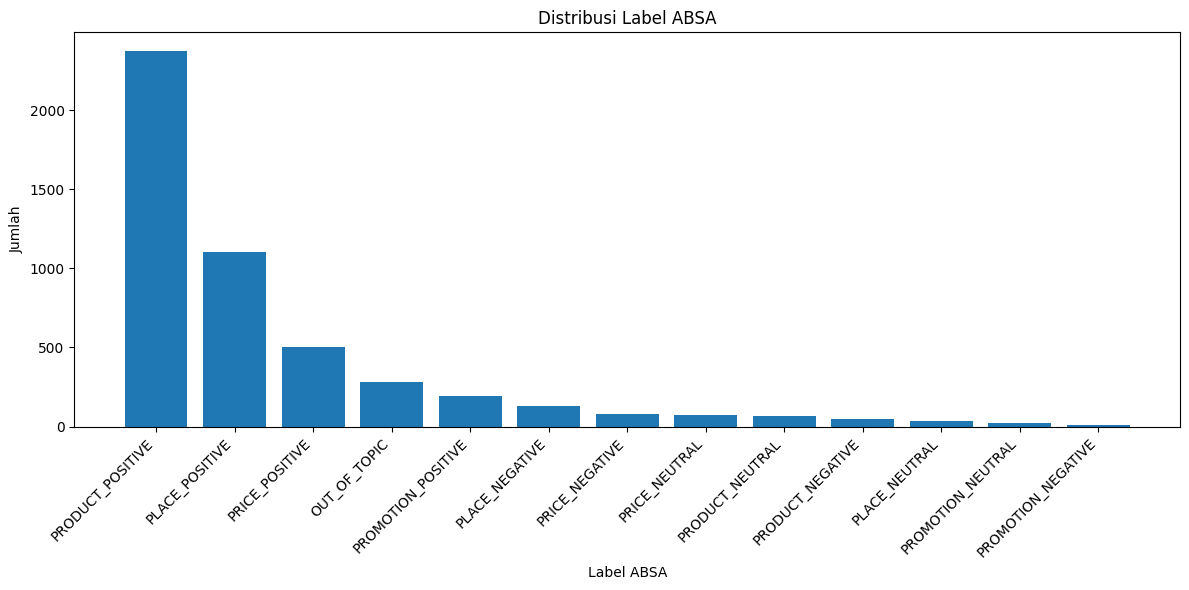

In [6]:
plt.figure(figsize=(12, 6))
plt.bar(label_df["label"], label_df["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Label ABSA")
plt.ylabel("Jumlah")
plt.title("Distribusi Label ABSA")
plt.tight_layout()
plt.show()

In [7]:
df["word_count"].describe()

count    3169.000000
mean       13.209845
std         9.820026
min         3.000000
25%         6.000000
50%        10.000000
75%        18.000000
max        53.000000
Name: word_count, dtype: float64

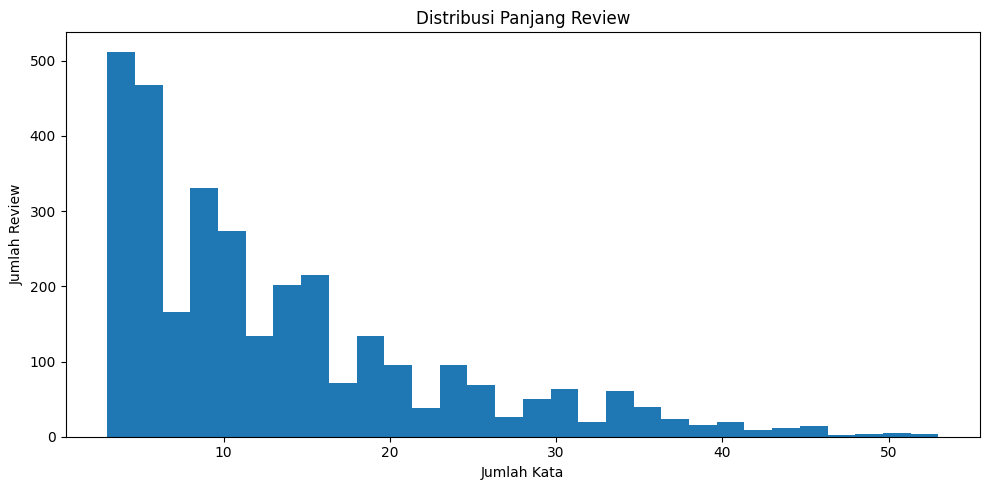

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df["word_count"], bins=30)
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Panjang Review")
plt.tight_layout()
plt.show()

In [9]:
num_label_counts = df["num_labels"].value_counts().sort_index()

num_label_counts

num_labels
0      31
1    1745
2    1049
3     306
4      35
5       3
Name: count, dtype: int64

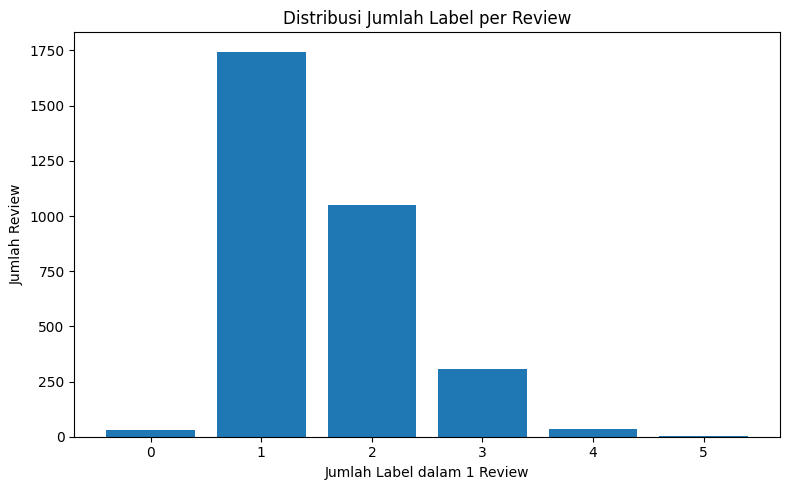

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(num_label_counts.index.astype(str), num_label_counts.values)
plt.xlabel("Jumlah Label dalam 1 Review")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Jumlah Label per Review")
plt.tight_layout()
plt.show()

In [11]:
all_unique_labels = sorted(set(all_labels))

for label in all_unique_labels:
    df[label] = df["accept"].apply(lambda labels: 1 if label in labels else 0)

df[["text"] + all_unique_labels].head()

,text,OUT_OF_TOPIC,PLACE_NEGATIVE,PLACE_NEUTRAL,PLACE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PRICE_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRODUCT_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,PROMOTION_POSITIVE
0,Pusat penjualan benda-benda seni dan segala ke...,0,0,0,0,0,0,0,0,0,1,0,0,0
1,Sering banget lewat tapi baru sempat mampir. B...,0,0,0,1,0,0,0,0,0,1,0,1,0
2,"pelayanan nya ramah-ramah banget, barang lengk...",0,0,0,1,0,0,1,0,0,1,0,0,0
3,Pusat penjualan benda-benda seni dan segala ke...,0,0,0,0,0,0,0,0,0,1,0,0,0
4,Sering banget lewat tapi baru sempat mampir. B...,0,0,0,1,0,0,0,0,0,1,0,1,0


In [12]:
corr_matrix = df[all_unique_labels].corr()

corr_matrix

,OUT_OF_TOPIC,PLACE_NEGATIVE,PLACE_NEUTRAL,PLACE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PRICE_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRODUCT_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,PROMOTION_POSITIVE
OUT_OF_TOPIC,1.000000,-0.063871,-0.020983,-0.190625,-0.049128,-0.040393,-0.107842,-0.030495,-0.046446,-0.462757,-0.015662,-0.027196,-0.056035
PLACE_NEGATIVE,-0.063871,1.000000,0.026322,-0.062790,0.082132,-0.020819,-0.005776,0.192682,-0.008643,-0.124895,0.021620,0.000566,-0.052247
PLACE_NEUTRAL,-0.020983,0.026322,1.000000,-0.029459,0.004001,0.067133,-0.027544,0.011957,0.069894,-0.019348,-0.005161,-0.008961,-0.000127
PLACE_POSITIVE,-0.190625,-0.062790,-0.029459,1.000000,-0.072549,-0.015346,0.049731,-0.066143,-0.072948,-0.050112,-0.036835,-0.002872,-0.036978
PRICE_NEGATIVE,-0.049128,0.082132,0.004001,-0.072549,1.000000,0.003091,-0.034895,0.095143,-0.023543,-0.031339,0.032902,-0.013785,-0.031618
PRICE_NEUTRAL,-0.040393,-0.020819,0.067133,-0.015346,0.003091,1.000000,-0.032160,-0.002562,0.020330,0.030831,-0.007725,0.010849,0.022465
PRICE_POSITIVE,-0.107842,-0.005776,-0.027544,0.049731,-0.034895,-0.032160,1.000000,-0.041137,-0.041135,0.164209,0.029775,0.011859,0.033820
PRODUCT_NEGATIVE,-0.030495,0.192682,0.011957,-0.066143,0.095143,-0.002562,-0.041137,1.000000,-0.001539,-0.095863,-0.006370,-0.011060,-0.032243
PRODUCT_NEUTRAL,-0.046446,-0.008643,0.069894,-0.072948,-0.023543,0.020330,-0.041135,-0.001539,1.000000,-0.217511,0.035583,-0.013033,-0.010870
PRODUCT_POSITIVE,-0.462757,-0.124895,-0.019348,-0.050112,-0.031339,0.030831,0.164209,-0.095863,-0.217511,1.000000,0.014667,0.000302,-0.028772


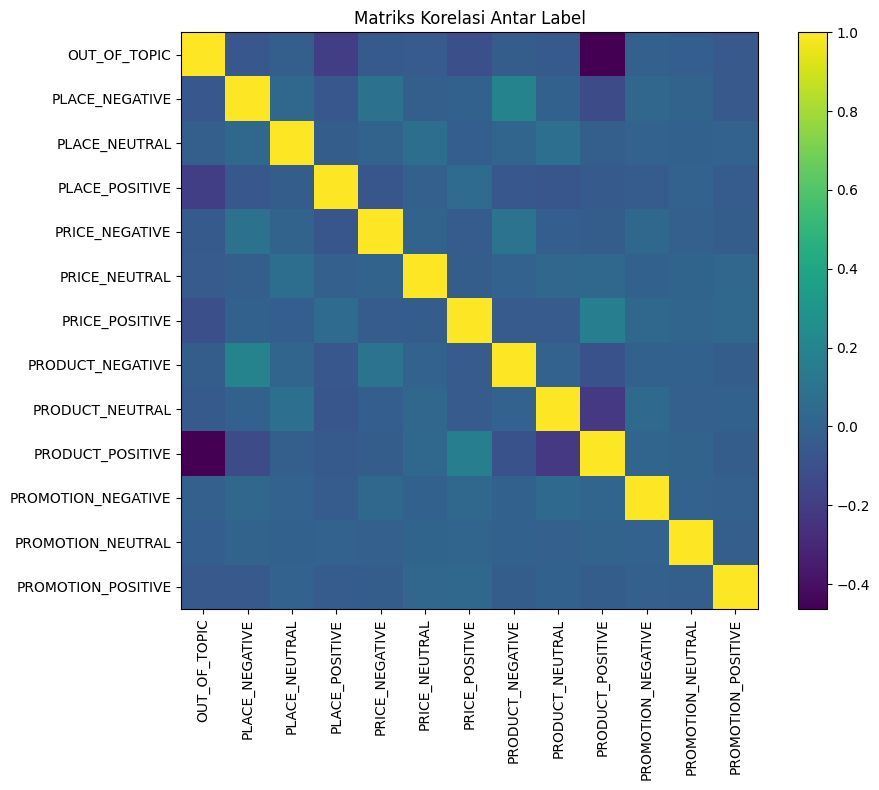

In [13]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.xticks(range(len(all_unique_labels)), all_unique_labels, rotation=90)
plt.yticks(range(len(all_unique_labels)), all_unique_labels)
plt.colorbar()
plt.title("Matriks Korelasi Antar Label")
plt.tight_layout()
plt.show()

In [14]:
def get_aspect(label):
    if label == "OUT_OF_TOPIC":
        return "OUT_OF_TOPIC"
    return label.split("_")[0]

aspect_counts = Counter([get_aspect(label) for label in all_labels])

aspect_df = pd.DataFrame(
    aspect_counts.items(),
    columns=["aspect", "count"]
).sort_values(by="count", ascending=False)

aspect_df

,aspect,count
0,PRODUCT,2491
1,PLACE,1267
3,PRICE,653
4,OUT_OF_TOPIC,280
2,PROMOTION,225


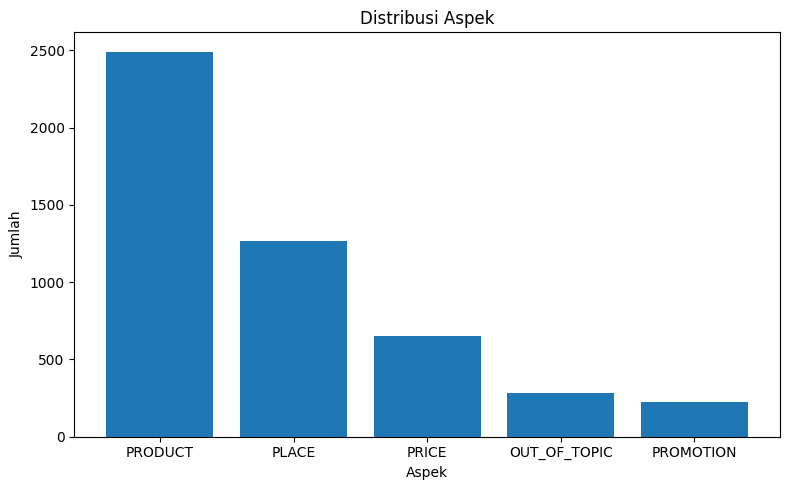

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(aspect_df["aspect"], aspect_df["count"])
plt.xlabel("Aspek")
plt.ylabel("Jumlah")
plt.title("Distribusi Aspek")
plt.tight_layout()
plt.show()

In [16]:
def get_sentiment(label):
    if label == "OUT_OF_TOPIC":
        return "OUT_OF_TOPIC"
    return label.split("_")[-1]

sentiment_counts = Counter([get_sentiment(label) for label in all_labels])

sentiment_df = pd.DataFrame(
    sentiment_counts.items(),
    columns=["sentiment", "count"]
).sort_values(by="count", ascending=False)

sentiment_df

,sentiment,count
0,POSITIVE,4174
3,OUT_OF_TOPIC,280
2,NEGATIVE,263
1,NEUTRAL,199


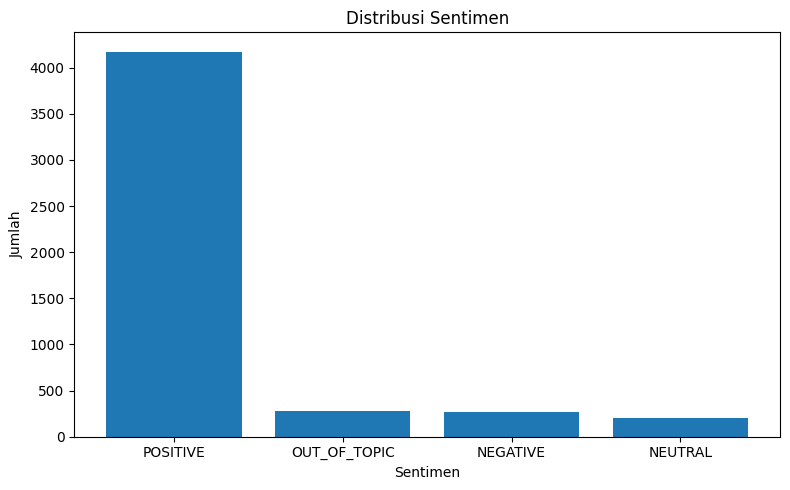

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(sentiment_df["sentiment"], sentiment_df["count"])
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.title("Distribusi Sentimen")
plt.tight_layout()
plt.show()

In [18]:
all_span_labels = []

if "spans" in df.columns:
    for spans in df["spans"]:
        if isinstance(spans, list):
            for span in spans:
                all_span_labels.append(span.get("label"))

span_counts = Counter(all_span_labels)

span_df = pd.DataFrame(
    span_counts.items(),
    columns=["entity_label", "count"]
).sort_values(by="count", ascending=False)

span_df

,entity_label,count
1,PRODUCT_POSITIVE,5304
2,PLACE_POSITIVE,1560
4,PRICE_POSITIVE,570
7,PROMOTION_POSITIVE,207
11,PLACE_NEGATIVE,184
0,OUT_OF_TOPIC,125
9,PRODUCT_NEUTRAL,90
5,PRICE_NEGATIVE,85
6,PRICE_NEUTRAL,74
8,PRODUCT_NEGATIVE,62


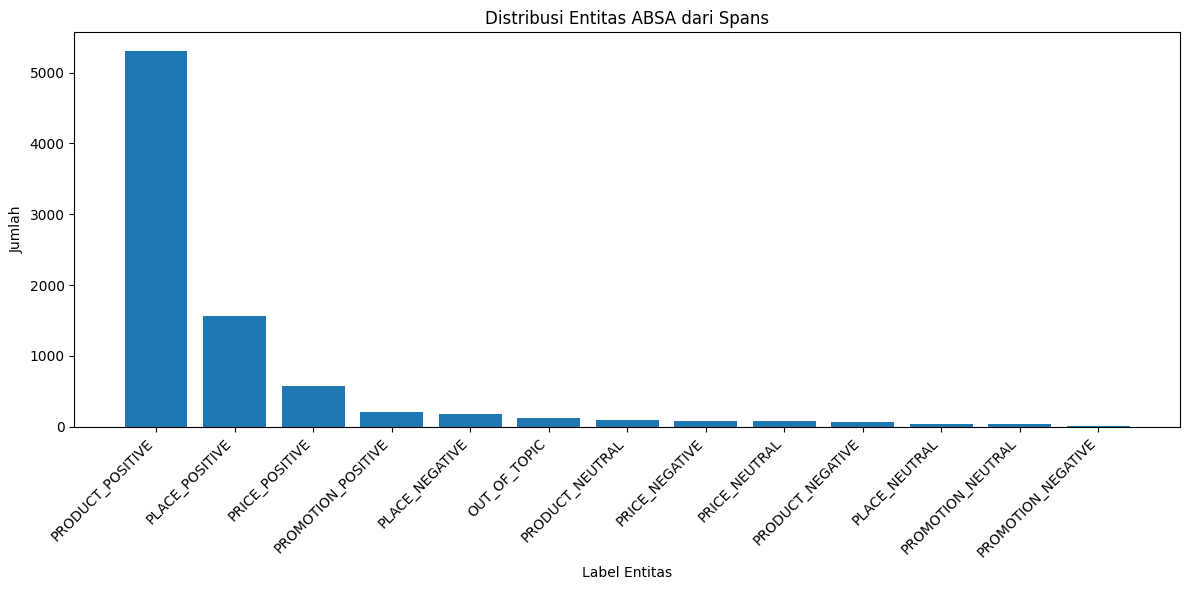

In [19]:
plt.figure(figsize=(12, 6))
plt.bar(span_df["entity_label"], span_df["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Label Entitas")
plt.ylabel("Jumlah")
plt.title("Distribusi Entitas ABSA dari Spans")
plt.tight_layout()
plt.show()

In [20]:
print("Jumlah total review:", len(df))
print("Rata-rata panjang review:", round(df["word_count"].mean(), 2), "kata")
print("Review terpendek:", df["word_count"].min(), "kata")
print("Review terpanjang:", df["word_count"].max(), "kata")
print("Rata-rata jumlah label per review:", round(df["num_labels"].mean(), 2))

print("\nLabel paling dominan:")
print(label_df.head(5))

print("\nAspek paling dominan:")
print(aspect_df.head())

print("\nSentimen paling dominan:")
print(sentiment_df.head())

Jumlah total review: 3169
Rata-rata panjang review: 13.21 kata
Review terpendek: 3 kata
Review terpanjang: 53 kata
Rata-rata jumlah label per review: 1.55

Label paling dominan:
                label  count
0    PRODUCT_POSITIVE   2372
1      PLACE_POSITIVE   1106
3      PRICE_POSITIVE    503
5        OUT_OF_TOPIC    280
7  PROMOTION_POSITIVE    193

Aspek paling dominan:
         aspect  count
0       PRODUCT   2491
1         PLACE   1267
3         PRICE    653
4  OUT_OF_TOPIC    280
2     PROMOTION    225

Sentimen paling dominan:
      sentiment  count
0      POSITIVE   4174
3  OUT_OF_TOPIC    280
2      NEGATIVE    263
1       NEUTRAL    199


In [ ]:
# Inter-Annotator Agreement (IRR)

# Load hasil IRR dari Prodigy
irr_file = "../hasil_anotasi/nlp3_iaaa.jsonl"

with open(irr_file, "r") as f:
    irr_data = json.load(f)

print("Hasil Inter-Annotator Agreement:")
print(f"Jumlah Annotator: {irr_data['n_annotators']}")
print(f"Rata-rata Rater per Contoh: {irr_data['avg_raters_per_example']:.2f}")
print(f"Pairwise F1: {irr_data['pairwise_f1']}")
print(f"Pairwise Recall: {irr_data['pairwise_recall']}")
print(f"Pairwise Precision: {irr_data['pairwise_precision']}")

# Interpretasi: Nilai IRR rendah (19%), perlu anotasi ulang untuk mencapai skor 5 (>=80)